# From 8 minutes to 4 seconds
## Solving large systems with Jacobi + GMRES

**Romain Sacchi (PSI) · Brightcon 2026 · 25 September 2026 · 8 minutes**  
Open Tools and Development · Aalborg University & online

> Direct sparse factorisation is an excellent default—until fill-in makes memory and runtime scale much faster than the matrix itself. An iterative solve makes that trade-off explicit and controllable.


## Run of show

1. Start with bare synthetic technosphere matrices and solve $Ax=b$ five ways.
2. Scale the same matrix family while measuring runtime, peak RSS, iterations, and residuals.
3. Reuse one fixed synthetic matrix across many right-hand sides.
4. Rebuild paired synthetic matrices across repeated samples.

Synthetic workers run in isolated subprocesses with explicit timeouts and a pre-construction memory
guard. Unsafe cells are labeled `SKIPPED`; failed or timed-out cells are preserved as diagnostics,
and only an unavailable live suite falls back to committed calibration results.


In [1]:
from __future__ import annotations

import importlib.metadata
import json
import os
import subprocess
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
from IPython.display import Markdown, display
from scipy.sparse.linalg import LinearOperator, gmres, spsolve


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "dev" / "benchmark_synthetic.py").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

LIVE = os.environ.get("BRIGHTCON_LIVE", "1") != "0"
BW_PROJECT = os.environ.get("BRIGHTCON_BW_PROJECT", "brightcon-2026")
DATABASE = "bafu"
ACTIVITY_CODE = "bafu-219622"
METHOD = ("IPCC 2021", "climate change", "global warming potential (GWP100)")
SEED = 2026
RTOL = 1e-4
try:
    import pypardiso  # noqa: F401
    PARDISO_AVAILABLE = True
except ImportError:
    PARDISO_AVAILABLE = False
DIRECT_SOLVERS = ["umfpack"] + (["pardiso"] if PARDISO_AVAILABLE else [])

{
    "live workers": LIVE,
    "worker Python": sys.executable,
    "Brightway project": BW_PROJECT,
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "scikit-umfpack": importlib.metadata.version("scikit-umfpack"),
}


{'live workers': True,
 'worker Python': '/opt/homebrew/Caskroom/miniforge/base/envs/jacobi-bw/bin/python',
 'Brightway project': 'brightcon-2026',
 'NumPy': '2.5.1',
 'SciPy': '1.18.0',
 'scikit-umfpack': '0.4.2'}

# 1 · Strip LCA down to $Ax=b$

- $A$: technosphere matrix—positive production diagonal, negative inputs.
- $b$: demand vector—one unit of the functional unit.
- $x$: supply array—how much each activity must produce.

The first matrix is deliberately ill-scaled across four orders of magnitude. This makes the purpose of diagonal preconditioning visible without any biosphere or characterization matrices.


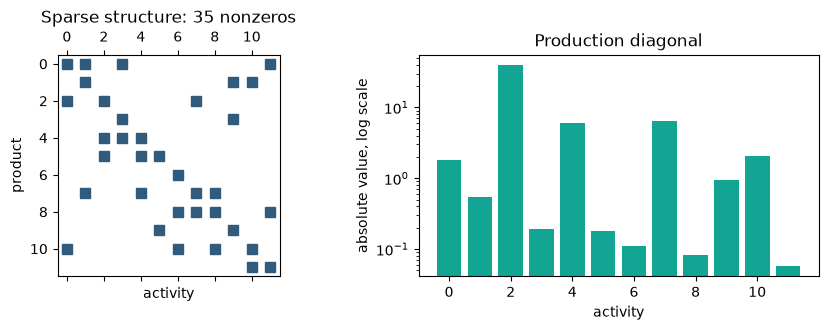

In [2]:
from dev.benchmark_synthetic import constant_degree_matrix

A_tiny = constant_degree_matrix(n=12, degree=2, seed=SEED, diagonal_span=4.0)
b_tiny = np.zeros(12)
b_tiny[0] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].spy(A_tiny, markersize=7, color="#315B7D")
axes[0].set_title(f"Sparse structure: {A_tiny.nnz} nonzeros")
axes[0].set_xlabel("activity")
axes[0].set_ylabel("product")
axes[1].bar(np.arange(12), np.abs(A_tiny.diagonal()), color="#12A594")
axes[1].set_yscale("log")
axes[1].set_title("Production diagonal")
axes[1].set_xlabel("activity")
axes[1].set_ylabel("absolute value, log scale")
fig.tight_layout()
plt.show()


## Five approaches, one solution

- Dense LAPACK through `numpy.linalg.solve`—useful only while $A$ is small.
- Sparse SuperLU, UMFPACK, and optionally Pardiso—robust direct factorisations.
- GMRES—approximate Krylov solve with an explicit residual tolerance.
- Jacobi + GMRES—left-precondition with $D^{-1}$, the reciprocal diagonal.

The entire Jacobi preconditioner is the `LinearOperator` below; no dense inverse is created.


In [3]:
def timed(function):
    started = perf_counter()
    value = function()
    return value, perf_counter() - started


def krylov(matrix, demand, *, jacobi: bool):
    history = []
    preconditioner = None
    if jacobi:
        inverse_diagonal = 1.0 / matrix.diagonal()
        preconditioner = LinearOperator(
            matrix.shape,
            matvec=lambda vector: inverse_diagonal * vector,
            dtype=matrix.dtype,
        )
    solution, info = gmres(
        matrix,
        demand,
        M=preconditioner,
        rtol=RTOL,
        atol=0.0,
        restart=50,
        maxiter=300,
        callback=history.append,
        callback_type="pr_norm",
    )
    return solution, info, len(history)


tiny_runs = []
tiny_solver_runs = [
    ("NumPy dense", lambda: (np.linalg.solve(A_tiny.toarray(), b_tiny), None, 0)),
    ("SuperLU", lambda: (spsolve(A_tiny, b_tiny, use_umfpack=False), None, 0)),
    ("UMFPACK", lambda: (spsolve(A_tiny, b_tiny, use_umfpack=True), None, 0)),
    ("GMRES", lambda: krylov(A_tiny, b_tiny, jacobi=False)),
    ("Jacobi + GMRES", lambda: krylov(A_tiny, b_tiny, jacobi=True)),
]
if PARDISO_AVAILABLE:
    from pypardiso import spsolve as pardiso_spsolve
    tiny_solver_runs.insert(3, ("Pardiso", lambda: (pardiso_spsolve(A_tiny, b_tiny), None, 0)))
for label, function in tiny_solver_runs:
    (solution, info, iterations), seconds = timed(function)
    residual = np.linalg.norm(A_tiny @ solution - b_tiny) / np.linalg.norm(b_tiny)
    tiny_runs.append(
        {"solver": label, "seconds": seconds, "iterations": iterations, "residual": residual, "info": info}
    )

pd.DataFrame(tiny_runs).style.format({"seconds": "{:.2e}", "residual": "{:.2e}"})


,solver,seconds,iterations,residual,info
0,NumPy dense,5.02e-05,0,1.51e-16,nan
1,SuperLU,1.52e-04,0,1.21e-17,nan
2,UMFPACK,2.13e-04,0,1.51e-16,nan
3,GMRES,3.83e-04,6,4.51e-05,0.000000
4,Jacobi + GMRES,1.59e-04,4,3.39e-05,0.000000


### Audience prompt

What happens to the benefit of Jacobi if every production diagonal is already one? The answer cell repeats the comparison on a unit-scaled matrix.


In [4]:
A_unit = constant_degree_matrix(n=500, degree=8, seed=SEED, diagonal_span=0.0)
b_unit = np.zeros(500)
b_unit[0] = 1.0
_, _, plain_iterations = krylov(A_unit, b_unit, jacobi=False)
_, _, jacobi_iterations = krylov(A_unit, b_unit, jacobi=True)
{"plain GMRES iterations": plain_iterations, "Jacobi + GMRES iterations": jacobi_iterations}


{'plain GMRES iterations': 4, 'Jacobi + GMRES iterations': 4}

# 2 · Scale the matrix, isolate every solver

Each solver runs in a fresh subprocess. This prevents one factorisation from contaminating the next solver's peak memory. A 2 ms RSS sampler captures allocations made by NumPy, SciPy, UMFPACK, and BLAS—not only Python objects. Incremental RSS is measured above the post-matrix-construction baseline.

Main series: approximately eight inputs per activity. Dense solving stops at 2,500 activities; the remaining isolated workers run to completion without a benchmark timeout.


In [5]:
def run_checked(command: list[str], timeout: float | None = None) -> subprocess.CompletedProcess[str]:
    return subprocess.run(
        command,
        cwd=ROOT,
        check=True,
        capture_output=True,
        text=True,
        timeout=timeout,
    )


def live_or_stored_synthetic():
    live_path = ROOT / "results" / "live_synthetic.json"
    fallback = ROOT / "results" / "synthetic_calibration.json"
    if LIVE:
        command = [
            sys.executable,
            "dev/run_synthetic_suite.py",
            "--python", sys.executable,
            "--output", str(live_path),
            "--sizes", "500", "1000", "2500", "5000", "10000",
            "--rtol", str(RTOL),
        ]
        try:
            run_checked(command)
            return json.loads(live_path.read_text()), "LIVE"
        except Exception as error:
            return json.loads(fallback.read_text()), f"STORED FALLBACK ({type(error).__name__})"
    return json.loads(fallback.read_text()), "STORED RESULTS"


synthetic_payload, synthetic_source = live_or_stored_synthetic()
display(Markdown(f"**Result source: {synthetic_source}**"))
synthetic = pd.json_normalize(synthetic_payload["results"])
synthetic["memory_mib"] = synthetic["incremental_peak_rss_bytes"] / 2**20
synthetic[["solver", "size", "solve_seconds", "memory_mib", "iterations", "relative_residual", "timed_out"]]


**Result source: LIVE**

,solver,size,solve_seconds,memory_mib,iterations,relative_residual,timed_out
0,numpy-dense,500,0.003178,11.046875,0.0,7.988388e-16,False
1,superlu,500,0.006099,4.062500,0.0,3.691832e-15,False
2,umfpack,500,0.004253,7.453125,0.0,5.612767e-16,False
3,pardiso,500,NaN,NaN,NaN,NaN,False
4,gmres,500,0.014518,0.312500,181.0,9.842808e-05,False
5,jacobi-gmres,500,0.000335,0.265625,6.0,4.452165e-05,False
6,numpy-dense,1000,0.008354,31.437500,0.0,1.261468e-16,False
7,superlu,1000,0.040889,19.796875,0.0,7.419040e-16,False
8,umfpack,1000,0.013983,21.281250,0.0,1.113162e-16,False
9,pardiso,1000,NaN,NaN,NaN,NaN,False


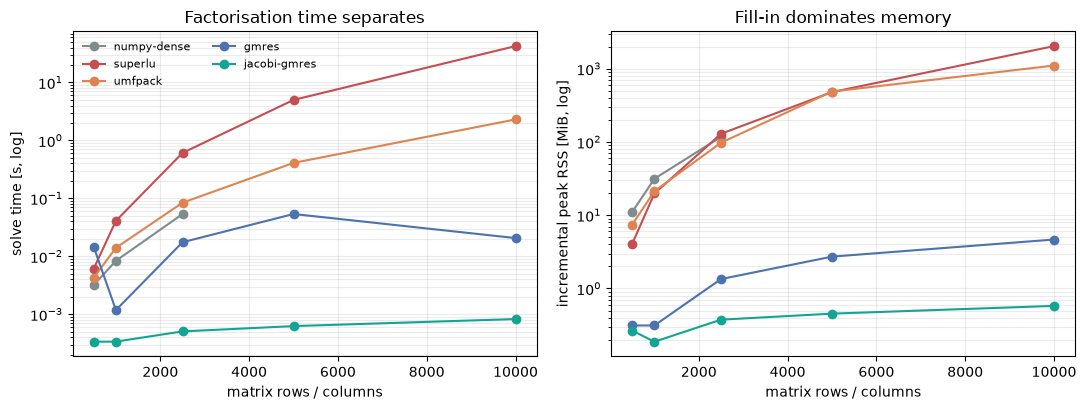

In [6]:
solver_order = ["numpy-dense", "superlu", *DIRECT_SOLVERS, "gmres", "jacobi-gmres"]
colors = {
    "numpy-dense": "#7F8C8D",
    "superlu": "#C44E52",
    "umfpack": "#DD8452",
    "pardiso": "#937860",
    "gmres": "#4C72B0",
    "jacobi-gmres": "#12A594",
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
valid = synthetic[synthetic["solve_seconds"].notna()]
for solver in solver_order:
    subset = valid[valid.solver == solver].sort_values("size")
    if subset.empty:
        continue
    axes[0].plot(subset["size"], subset["solve_seconds"], "o-", label=solver, color=colors[solver])
    axes[1].plot(subset["size"], subset["memory_mib"], "o-", label=solver, color=colors[solver])

axes[0].set_yscale("log")
axes[0].set_ylabel("solve time [s, log]")
axes[1].set_yscale("log")
axes[1].set_ylabel("incremental peak RSS [MiB, log]")
for axis in axes:
    axis.set_xlabel("matrix rows / columns")
    axis.grid(alpha=0.25, which="both")
axes[0].set_title("Factorisation time separates")
axes[1].set_title("Fill-in dominates memory")
axes[0].legend(frameon=False, ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


### Connectivity versus size

The first scaling curve keeps roughly eight inputs per activity. This additional sweep holds the
number of inputs per activity at 5 or 25 while changing matrix size. It separates the effect of
database size from the effect of denser connectivity.


In [7]:
def live_or_stored_connectivity():
    live_path = ROOT / "results" / "live_connectivity.json"
    fallback = ROOT / "results" / "synthetic_connectivity_calibration.json"
    if LIVE:
        command = [
            sys.executable, "dev/run_synthetic_suite.py", "--python", sys.executable,
            "--output", str(live_path), "--sizes", "1000", "5000", "10000",
            "--solvers", *DIRECT_SOLVERS, "jacobi-gmres", "--topology", "constant-degree",
            "--degrees", "5", "25", "--rtol", str(RTOL), "--run-timeout", "60",
        ]
        try:
            run_checked(command)
            return json.loads(live_path.read_text()), "LIVE"
        except Exception as error:
            return json.loads(fallback.read_text()), f"STORED FALLBACK ({type(error).__name__})"
    return json.loads(fallback.read_text()), "STORED RESULTS"


connectivity_payload, connectivity_source = live_or_stored_connectivity()
display(Markdown(f"**Result source: {connectivity_source}**"))
connectivity = pd.json_normalize(connectivity_payload["results"])
connectivity["memory_mib"] = connectivity["incremental_peak_rss_bytes"] / 2**20
connectivity["speedup_vs_umfpack"] = np.nan
for (size, degree), subset in connectivity.groupby(["size", "degree"]):
    direct = subset.loc[subset.solver == "umfpack", "solve_seconds"]
    if len(direct) == 1:
        connectivity.loc[subset.index, "speedup_vs_umfpack"] = direct.iloc[0] / subset["solve_seconds"]
display(connectivity[["solver", "size", "degree", "solve_seconds", "memory_mib", "speedup_vs_umfpack", "status"]])


**Result source: LIVE**

,solver,size,degree,solve_seconds,memory_mib,speedup_vs_umfpack,status
0,umfpack,1000,5,0.008529,13.500000,1.000000,COMPLETED
1,jacobi-gmres,1000,5,0.000307,0.156250,27.801543,COMPLETED
2,umfpack,1000,25,0.020675,47.015625,1.000000,COMPLETED
3,jacobi-gmres,1000,25,0.000438,0.156250,47.153890,COMPLETED
4,umfpack,5000,5,0.222504,188.203125,1.000000,COMPLETED
5,jacobi-gmres,5000,5,0.000481,0.625000,462.265640,COMPLETED
6,umfpack,5000,25,0.669239,616.078125,1.000000,COMPLETED
7,jacobi-gmres,5000,25,0.001079,0.468750,620.072267,COMPLETED
8,umfpack,10000,5,1.411789,762.171875,1.000000,COMPLETED
9,jacobi-gmres,10000,5,0.000569,0.546875,2482.990134,COMPLETED


### Large synthetic systems

The same fixed-connectivity construction is also attempted at 50,000, 100,000, and 300,000 rows.
Dense and SuperLU are omitted at these sizes; UMFPACK, GMRES, and Jacobi + GMRES run in isolated
workers with explicit status, timeout, and total-budget fields.


In [8]:
def live_or_stored_large_scaling():
    live_path = ROOT / "results" / "live_synthetic_large.json"
    fallback = ROOT / "results" / "synthetic_large_calibration.json"
    if LIVE:
        available_mib = psutil.virtual_memory().available / 2**20
        construction_guard_mib = int(min(8192, max(512, available_mib * 0.25)))
        command = [
            sys.executable, "dev/run_synthetic_suite.py", "--python", sys.executable,
            "--output", str(live_path), "--sizes", "50000", "100000", "300000",
            "--solvers", *DIRECT_SOLVERS, "gmres", "jacobi-gmres",
            "--topology", "constant-degree", "--degree", "8", "--rtol", str(RTOL),
            "--run-timeout", "120", "--total-budget", "900",
            "--max-estimated-construction-mib", str(construction_guard_mib),
        ]
        try:
            run_checked(command, timeout=960)
            return json.loads(live_path.read_text()), "LIVE"
        except Exception as error:
            return json.loads(fallback.read_text()), f"STORED FALLBACK ({type(error).__name__})"
    return json.loads(fallback.read_text()), "STORED RESULTS"


large_payload, large_source = live_or_stored_large_scaling()
display(Markdown(f"**Result source: {large_source}**"))
large_results = pd.json_normalize(large_payload["results"])
large_results["memory_mib"] = large_results["incremental_peak_rss_bytes"] / 2**20
display(large_results[["solver", "size", "degree", "nnz", "status", "worker_wall_seconds", "solve_seconds", "memory_mib", "iterations", "relative_residual"]])


**Result source: LIVE**

,solver,size,degree,nnz,status,worker_wall_seconds,solve_seconds,memory_mib,iterations,relative_residual
0,umfpack,50000,8,NaN,FAILED,1.025668,NaN,NaN,NaN,NaN
1,gmres,50000,8,449961.0,COMPLETED,0.228714,0.036449,15.468750,25.0,0.000081
2,jacobi-gmres,50000,8,449961.0,COMPLETED,0.195460,0.004633,4.687500,4.0,0.000022
3,umfpack,100000,8,NaN,FAILED,2.195512,NaN,NaN,NaN,NaN
4,gmres,100000,8,899973.0,COMPLETED,0.264743,0.052328,29.437500,24.0,0.000091
5,jacobi-gmres,100000,8,899973.0,COMPLETED,0.218145,0.008067,15.671875,4.0,0.000028
6,umfpack,300000,8,NaN,FAILED,6.818773,NaN,NaN,NaN,NaN
7,gmres,300000,8,2699974.0,COMPLETED,2.977799,2.687979,157.343750,278.0,0.000099
8,jacobi-gmres,300000,8,2699974.0,COMPLETED,0.324020,0.032572,44.578125,6.0,0.000072


## Guarded size–density stress test

With constant density, nonzeros grow with $n^2$, not $n$. The guarded grid below adds 0.3%, 1%,
3%, 5%, 10%, and 15% density to the original 0.1% case. High-density cases are intentionally
limited to smaller matrices: the pre-construction guard labels unsafe cases `SKIPPED` instead of
allocating them. The `io-block` family is also included to show that density alone does not capture
input-output structure.


**Result source: LIVE**

,solver,size,target_density,nnz,runtime_status,solve_seconds,incremental_peak_MiB,iterations,relative_residual
0,umfpack,1000,0.001,2000.0,COMPLETED,0.000284,0.609375,0.0,0.000000
1,gmres,1000,0.001,2000.0,COMPLETED,0.000179,0.187500,1.0,0.000000
2,jacobi-gmres,1000,0.001,2000.0,COMPLETED,0.000186,0.218750,1.0,0.000000
3,umfpack,1000,0.003,3998.0,COMPLETED,0.003762,4.562500,0.0,0.000000
4,gmres,1000,0.003,3998.0,COMPLETED,0.000192,0.140625,1.0,0.000000
...,...,...,...,...,...,...,...,...,...
100,gmres,20000,0.100,40018002.0,COMPLETED,4.825454,8.890625,154.0,0.000099
101,jacobi-gmres,20000,0.100,40018002.0,COMPLETED,0.215407,3.500000,5.0,0.000036
102,umfpack,20000,0.150,NaN,FAILED,NaN,NaN,NaN,NaN
103,gmres,20000,0.150,60017064.0,COMPLETED,0.660591,3.265625,15.0,0.000088


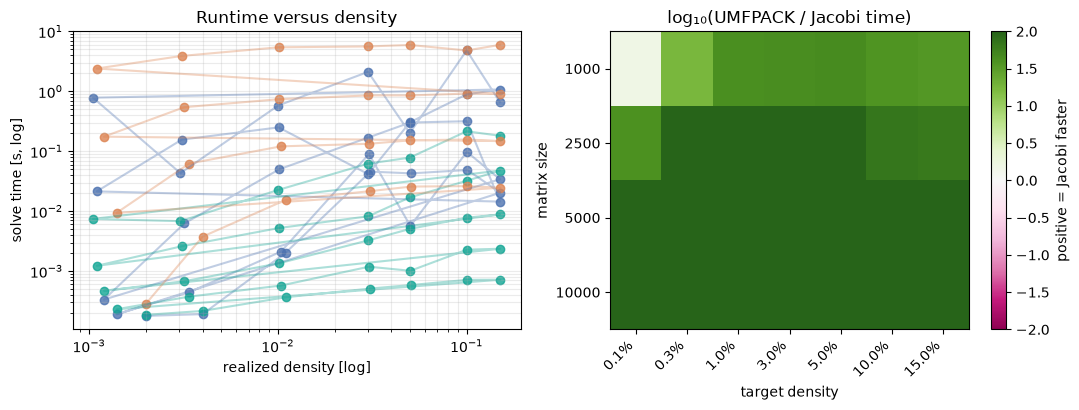

In [9]:
def live_or_stored_density_grid():
    live_path = ROOT / "results" / "live_density_grid.json"
    fallback = ROOT / "results" / "synthetic_density_grid_calibration.json"
    if LIVE:
        available_mib = psutil.virtual_memory().available / 2**20
        construction_guard_mib = int(min(8192, max(512, available_mib * 0.25)))
        command = [
            sys.executable, "dev/run_synthetic_suite.py", "--python", sys.executable,
            "--output", str(live_path), "--sizes", "1000", "2500", "5000", "10000", "20000",
            "--solvers", *DIRECT_SOLVERS, "gmres", "jacobi-gmres",
            "--topology", "fixed-density", "--densities",
            "0.001", "0.003", "0.01", "0.03", "0.05", "0.1", "0.15",
            "--matrix-family", "lca-random", "--rtol", str(RTOL),
            "--run-timeout", "90", "--total-budget", "900", "--max-estimated-construction-mib", str(construction_guard_mib),
            "--construction-memory-multiplier", "3",
        ]
        try:
            run_checked(command, timeout=600)
            return json.loads(live_path.read_text()), "LIVE"
        except Exception as error:
            return json.loads(fallback.read_text()), f"STORED FALLBACK ({type(error).__name__})"
    return json.loads(fallback.read_text()), "STORED RESULTS"


density_payload, density_source = live_or_stored_density_grid()
display(Markdown(f"**Result source: {density_source}**"))
density_results = pd.json_normalize(density_payload["results"])
density_results["incremental_peak_MiB"] = density_results["incremental_peak_rss_bytes"] / 2**20
density_results["runtime_status"] = density_results.get("status", "COMPLETED")
display(density_results[["solver", "size", "target_density", "nnz", "runtime_status", "solve_seconds", "incremental_peak_MiB", "iterations", "relative_residual"]])

completed = density_results[density_results.runtime_status == "COMPLETED"].copy()
completed["log10_speedup_umfpack_over_jacobi"] = np.nan
for (size, density), subset in completed.groupby(["size", "target_density"]):
    direct = subset.loc[subset.solver == "umfpack", "solve_seconds"]
    iterative = subset.loc[subset.solver == "jacobi-gmres", "solve_seconds"]
    if len(direct) == 1 and len(iterative) == 1:
        value = np.log10(direct.iloc[0] / iterative.iloc[0])
        completed.loc[subset.index, "log10_speedup_umfpack_over_jacobi"] = value

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for solver, subset in completed.groupby("solver"):
    axes[0].scatter(subset["density"], subset["solve_seconds"], label=solver, color=colors[solver], alpha=0.8)
    axes[0].plot(subset["density"], subset["solve_seconds"], color=colors[solver], alpha=0.35)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("realized density [log]")
axes[0].set_ylabel("solve time [s, log]")
axes[0].set_title("Runtime versus density")
axes[0].grid(alpha=0.25, which="both")

pivot = completed[completed.solver == "jacobi-gmres"].pivot_table(index="size", columns="target_density", values="log10_speedup_umfpack_over_jacobi")
image = axes[1].imshow(pivot, aspect="auto", cmap="PiYG", vmin=-2, vmax=2)
axes[1].set_xticks(range(len(pivot.columns)), [f"{value:.1%}" for value in pivot.columns], rotation=45, ha="right")
axes[1].set_yticks(range(len(pivot.index)), pivot.index)
axes[1].set_xlabel("target density")
axes[1].set_ylabel("matrix size")
axes[1].set_title("log₁₀(UMFPACK / Jacobi time)")
fig.colorbar(image, ax=axes[1], label="positive = Jacobi faster")
fig.tight_layout()
plt.show()


### Matrix structure sensitivity

At the same nominal densities, block-structured input-output matrices can behave differently from
uniform random cross-links. This small companion sweep keeps the high-density cases bounded while
showing that density is a proxy for structure, not a complete explanation.


In [10]:
def live_or_stored_io_block():
    live_path = ROOT / "results" / "live_density_ioblock.json"
    fallback = ROOT / "results" / "synthetic_density_ioblock_calibration.json"
    if LIVE:
        available_mib = psutil.virtual_memory().available / 2**20
        construction_guard_mib = int(min(8192, max(512, available_mib * 0.25)))
        command = [
            sys.executable, "dev/run_synthetic_suite.py", "--python", sys.executable,
            "--output", str(live_path), "--sizes", "1000", "2500", "5000", "10000",
            "--solvers", *DIRECT_SOLVERS, "jacobi-gmres", "--topology", "fixed-density",
            "--densities", "0.01", "0.05", "0.15", "--matrix-family", "io-block",
            "--blocks", "8", "--rtol", str(RTOL), "--run-timeout", "90", "--total-budget", "600",
            "--max-estimated-construction-mib", str(construction_guard_mib),
        ]
        try:
            run_checked(command, timeout=300)
            return json.loads(live_path.read_text()), "LIVE"
        except Exception as error:
            return json.loads(fallback.read_text()), f"STORED FALLBACK ({type(error).__name__})"
    return json.loads(fallback.read_text()), "STORED RESULTS"


ioblock_payload, ioblock_source = live_or_stored_io_block()
display(Markdown(f"**Result source: {ioblock_source}**"))
ioblock = pd.json_normalize(ioblock_payload["results"])
ioblock["memory_mib"] = ioblock["incremental_peak_rss_bytes"] / 2**20
display(ioblock[["solver", "size", "target_density", "nnz", "solve_seconds", "memory_mib", "iterations", "status"]])


**Result source: LIVE**

,solver,size,target_density,nnz,solve_seconds,memory_mib,iterations,status
0,umfpack,1000,0.01,10930,0.014646,29.562500,0,COMPLETED
1,jacobi-gmres,1000,0.01,10930,0.000309,0.125000,4,COMPLETED
2,umfpack,1000,0.05,50264,0.024383,39.937500,0,COMPLETED
3,jacobi-gmres,1000,0.05,50264,0.000631,0.453125,8,COMPLETED
4,umfpack,1000,0.15,146453,0.024985,49.796875,0,COMPLETED
5,jacobi-gmres,1000,0.15,146453,0.000900,0.156250,7,COMPLETED
6,umfpack,2500,0.01,64754,0.127160,147.812500,0,COMPLETED
7,jacobi-gmres,2500,0.01,64754,0.000680,0.531250,6,COMPLETED
8,umfpack,2500,0.05,311679,0.133696,182.328125,0,COMPLETED
9,jacobi-gmres,2500,0.05,311679,0.001632,0.171875,7,COMPLETED


# 3 · Fixed matrix, many right-hand sides

One fixed technosphere matrix can serve many demands. UMFPACK factorizes once and reuses its factors;
Jacobi + GMRES solves each right-hand side iteratively.


,solver,rhs_count,factorization_seconds,rhs_solve_seconds,solve_seconds,relative_residual
0,umfpack,1,0.383730,0.025573,0.411387,6.287716e-16
1,jacobi-gmres,1,0.000000,0.000679,0.000681,4.547882e-05
2,umfpack,10,0.378801,0.221331,0.602156,3.479800e-15
3,jacobi-gmres,10,0.000000,0.004950,0.004952,7.415673e-05
4,umfpack,100,0.385716,2.269050,2.656729,8.990907e-15
5,jacobi-gmres,100,0.000000,0.042381,0.042383,8.783257e-05
6,umfpack,1000,0.400223,22.726434,23.128608,2.298050e-14
7,jacobi-gmres,1000,0.000000,0.402059,0.402062,9.914484e-05


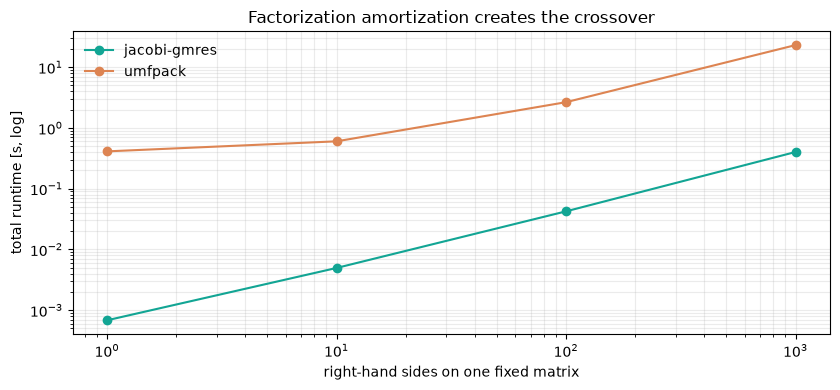

In [11]:
rhs_output = ROOT / "results" / "live_synthetic_rhs_sweep.json"
rhs_command = [sys.executable, "dev/run_synthetic_suite.py", "--python", sys.executable,
    "--output", str(rhs_output), "--sizes", "5000", "--solvers", *DIRECT_SOLVERS, "jacobi-gmres",
    "--topology", "constant-degree", "--degree", "8", "--rhs-counts", "1", "10", "100", "1000",
    "--rtol", str(RTOL), "--run-timeout", "120"]
run_checked(rhs_command, timeout=600)
rhs = pd.json_normalize(json.loads(rhs_output.read_text())["results"])
display(rhs[["solver", "rhs_count", "factorization_seconds", "rhs_solve_seconds", "solve_seconds", "relative_residual"]])
fig, axis = plt.subplots(figsize=(8.5, 4))
for solver, subset in rhs.groupby("solver"):
    axis.plot(subset["rhs_count"], subset["solve_seconds"], "o-", label=solver, color=colors[solver])
axis.set_xscale("log"); axis.set_yscale("log")
axis.set_xlabel("right-hand sides on one fixed matrix"); axis.set_ylabel("total runtime [s, log]")
axis.set_title("Factorization amortization creates the crossover"); axis.grid(alpha=0.25, which="both")
axis.legend(frameon=False); fig.tight_layout(); plt.show()


# 4 · Changing matrix, repeated solves

This synthetic Monte Carlo analogue rebuilds the technosphere matrix for every sample. Both solvers
receive the same paired matrices and demand; residuals and convergence are recorded.


,solver,sample,solve_seconds,iterations,relative_residual,info
20,umfpack,TOTAL,7.585935,0,1.320736e-14,NaN
41,jacobi-gmres,TOTAL,0.038902,6,9.566686e-05,NaN


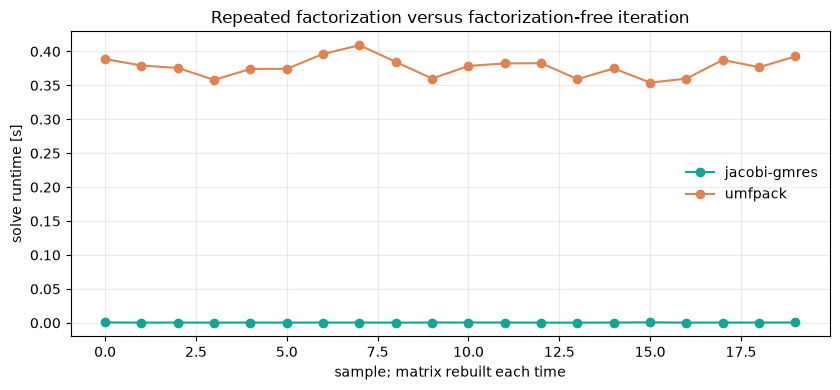

In [12]:
from dev.benchmark_synthetic import constant_degree_matrix, solve
demand = np.zeros(5000); demand[0] = 1.0
records = []
for solver in (*DIRECT_SOLVERS, "jacobi-gmres"):
    started = perf_counter(); residuals = []; iterations = []
    for sample in range(20):
        matrix = constant_degree_matrix(5000, 8, SEED + sample, 4.0)
        solve_started = perf_counter()
        solution, info, count = solve(matrix, demand, solver, RTOL, 50, 300)
        elapsed = perf_counter() - solve_started
        residual = float(np.linalg.norm(matrix @ solution - demand) / np.linalg.norm(demand))
        residuals.append(residual); iterations.append(count)
        records.append({"solver": solver, "sample": sample, "solve_seconds": elapsed, "iterations": count, "relative_residual": residual, "info": info})
    records.append({"solver": solver, "sample": "TOTAL", "solve_seconds": perf_counter() - started, "iterations": int(np.median(iterations)), "relative_residual": max(residuals), "info": None})
changing = pd.DataFrame(records)
display(changing[changing["sample"] == "TOTAL"])
fig, axis = plt.subplots(figsize=(8.5, 4))
for solver, subset in changing[changing["sample"] != "TOTAL"].groupby("solver"):
    axis.plot(subset["sample"], subset["solve_seconds"], "o-", label=solver, color=colors[solver])
axis.set_xlabel("sample; matrix rebuilt each time"); axis.set_ylabel("solve runtime [s]")
axis.set_title("Repeated factorization versus factorization-free iteration"); axis.grid(alpha=0.25)
axis.legend(frameon=False); fig.tight_layout(); plt.show()


# 5 · JacobiGMRESLCA in bw2calc

In Brightway, `bw2calc.JacobiGMRESLCA` changes the technosphere solve while leaving biosphere and
characterization processing unchanged. Main arguments are `demand`, `method`, `rtol`, `use_guess`,
`restart`, and `maxiter`.

```python
from bw2calc import JacobiGMRESLCA
lca = JacobiGMRESLCA({activity.id: 1.0}, method, rtol=1e-4, use_guess=True)
lca.lci()
lca.lcia()
print(lca.score)
```

Check convergence, residual, and agreement before interpreting an iterative score.


# When to use Jacobi + GMRES

Use it when the technosphere is very large and sparse, the matrix changes repeatedly, or direct
factorization approaches the machine memory limit and a controlled tolerance is acceptable.

Prefer direct UMFPACK or Pardiso when the matrix is small or moderate, many demands reuse one fixed
matrix, exact/direct solves are required, or factorization fits comfortably in memory and can be
amortized. Decide from measured factorization cost, memory, convergence, and agreement—not runtime
alone.


# Takeaways

1. **The crossover is structural.** As random cross-links and density generate fill-in, direct runtime and RAM rise sharply.
2. **A fixed matrix favors reuse.** Direct factorization amortizes across many right-hand sides.
3. **Changing matrices favor factorization-free iteration.** Jacobi+GMRES avoids paying a new LU factorization each sample.
4. **Approximation must be audited.** Report `rtol`, GMRES status, the measured $Ax-b$ residual, and solution agreement.
5. **Large systems change the practical limit.** Jacobi+GMRES can remain feasible after direct factorization runs out of memory.

> Use direct solving by default; switch when measured factorisation cost—not fashion—justifies it.


## Presenter preflight—not part of the timed talk

- Run once on the conference VM with `BRIGHTCON_LIVE=1`.
- Confirm the direct backend is UMFPACK or explicitly relabel it if Pardiso is used.
- Keep the committed results as a fallback, but never present them as live output.
